## Simple Linear Regression Involves (Only One Input Variable)

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#read the datasets
dataset=pd.read_csv("weight-height.csv")

In [4]:
dataset.head(10)

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
5,Male,67.253016,152.212156
6,Male,68.785081,183.927889
7,Male,68.348516,167.971110
8,Male,67.018950,175.929440
9,Male,63.456494,156.399676


In [5]:
dataset.isna().sum()

Gender    0
Height    0
Weight    0
dtype: int64

In [6]:
dataset.shape

(10000, 3)

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [8]:
dataset.Gender=dataset.Gender.apply(lambda x: 1 if x=="Male" else 0)

In [9]:
dataset.corr()

,Gender,Height,Weight
Gender,1.000000,0.691072,0.796723
Height,0.691072,1.000000,0.924756
Weight,0.796723,0.924756,1.000000


## Lets check the correlation between each variables

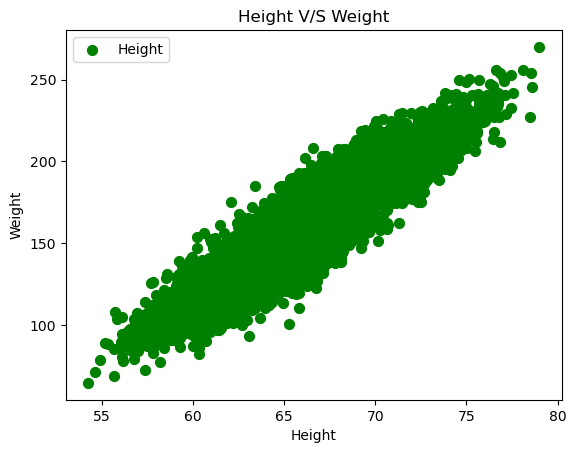

In [10]:
#Lets we plotting Height V/S Weight
x1=dataset.Height
y1=dataset.Weight
plt.scatter(x1,y1,label="Height",color="Green",s=50)
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Height V/S Weight")
plt.legend()
plt.show()

In [11]:
dataset.Height.corr(dataset.Weight)

np.float64(0.9247562987409146)

* If we Find that in our dataset there is the correllation is good so we can follow these steps
# Step1:
     - Load Data
      - Cleaning Process
# Step2:
     - Problem Identification (Regression/Classification)
# Step3:
     - Data Seperate input and output (x and y)
# Step4:
    - Split the data into training data and testing Data
# Step5:
    - Select model / Algorithm
# Step6:
    - Train the model / Fit the model
# Step7:
    - Evaluate the models performance on training data
# Step8:
    - Evaluate on testing Data
# Step9:
    - Evaluate the model performance on testing data
# Step10:
    - Deployed model prediction 

## Since The Target Column is Continous : Regression

In [12]:
#STEP3.1: Seperate predictors and target(input and output x and y)
# X- Independent variable

#If the columns are more so we drop the target column and the all other columns are safe
X= dataset.drop(["Weight","Gender"],axis=1)  #Or dataset[["Height"]]
print(X)

         Height
0     73.847017
1     68.781904
2     74.110105
3     71.730978
4     69.881796
...         ...
9995  66.172652
9996  67.067155
9997  63.867992
9998  69.034243
9999  61.944246

[10000 rows x 1 columns]


In [13]:
#dependent or target variable
y= dataset[["Weight"]]
print(y)

          Weight
0     241.893563
1     162.310473
2     212.740856
3     220.042470
4     206.349801
...          ...
9995  136.777454
9996  170.867906
9997  128.475319
9998  163.852461
9999  113.649103

[10000 rows x 1 columns]


* Spliting the dataset into training and test set 

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.30,random_state=123)

In [15]:
X_train.shape,X_test.shape

((7000, 1), (3000, 1))

In [16]:
from sklearn.linear_model import LinearRegression
slr = LinearRegression()   #slr(Simple linear regression)

In [17]:
slr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
slr.coef_    #This is slope(coefficient)

array([[7.72406641]])

In [19]:
slr.intercept_

array([-351.29837817])

# Prediction On Training Data

In [20]:
y_pred=slr.predict(X_train)

In [21]:
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error

In [22]:
root_mean_squared_error(y_train,y_pred)

12.254376567955005

In [23]:
mean_absolute_error(y_train,y_pred)

9.740401522393444

In [24]:
r2_score(y_train,y_pred)

0.8522506436970537

In [25]:
y_pred_test=slr.predict(X_test)

In [26]:
r2_score(y_test,y_pred_test)

0.8616393610516163

In [27]:
def predict_weight(height):
    return slr.predict(height)*0.45   # We can multiply it by 0.45 because 1 pound is equals to 0.45 Kg

In [28]:
height_inch=float(input("Enter Your Height in foot:"))*12

predict_weight([[height_inch]])  # We give data in two dimensional array form 

Enter Your Height in foot: 6


D:\Users\hp\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[92.17548153]])

In [29]:
import joblib

In [30]:
joblib.dump(slr,'slr.joblib')

['slr.joblib']

# Multiple Linear Regresion 

In [32]:
dataset.corr()

,Gender,Height,Weight
Gender,1.000000,0.691072,0.796723
Height,0.691072,1.000000,0.924756
Weight,0.796723,0.924756,1.000000


In [33]:
X = dataset.drop("Weight",axis=1)
y = dataset[["Weight"]]

In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.30,random_state=123)

In [43]:
X_test.shape,X_train.shape,y_train.shape,y_test.shape

((3000, 2), (7000, 2), (7000, 1), (3000, 1))

In [44]:
from sklearn.linear_model import LinearRegression
mlr=LinearRegression()

In [45]:
mlr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
mlr.coef_

array([[19.44853375,  5.96315161]])

In [49]:
mlr.intercept_

array([-244.15291309])

In [50]:
y_predict_train=mlr.predict(X_train)

In [51]:
y_predict_test= mlr.predict(X_test)

In [52]:
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error

In [56]:
r2_score(y_train,y_predict_train)

0.9009914639586475

In [57]:
r2_score(y_test,y_predict_test)

0.9066151030846359

In [70]:
joblib.dump(mlr,'mlr.joblib')

['mlr.joblib']